### **Import libraries**

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, roc_auc_score, roc_curve, auc, confusion_matrix
from sklearn.metrics import make_scorer, balanced_accuracy_score, confusion_matrix
import shap

from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, label_binarize

import matplotlib.pyplot as plt
from matplotlib import pyplot
import seaborn as sns

import lightgbm as lgb
from catboost import CatBoostClassifier

# warnings
import warnings
warnings.filterwarnings("ignore")

### Load the preprocessed dataset

In [2]:
# Load NSCLC gene expression dataset (GSE81089)
df = pd.read_csv("preprocessed_dataset.csv") 
labels = df["diagnosis"] # 1=squamous cell cancer, 2=AC unspecified, 3=Large cell/ NOS
gene_data = df.drop(columns=["sample_id","diagnosis","stage"])

print("Data shape: ", gene_data.shape)
gene_data.head()

Data shape:  (199, 56685)


,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,RP11__415F23.4,CYP2D6.2,SNORA28,Metazoa_SRP.33,GS1__166A23.1,XXbac__BPG252P9.9,XXbac__BPGBPG55C20.1,RP11__255P5.2,MIR4787,CTC__527H23.4
0,52.1950,0.230061,43.8616,14.71010,4.81335,7.40831,112.4260,43.9196,12.12890,13.3027,...,0.215946,0.0,0.0,0.0,0.0,1.38909,0.312571,0.086774,0.0,0.000000
1,37.8891,0.086034,47.0457,7.81233,5.92073,9.83188,39.7146,60.4056,9.20525,19.6343,...,0.583569,0.0,0.0,0.0,0.0,1.15011,0.050841,0.000000,0.0,0.000000
2,23.1910,0.048022,38.1292,12.31170,8.21385,9.68575,25.9596,49.0519,23.92220,20.1660,...,0.088140,0.0,0.0,0.0,0.0,1.11998,0.551958,0.036071,0.0,0.000000
3,25.0324,0.000000,54.3030,8.41631,6.71221,10.92630,80.2073,40.4700,46.93690,20.1807,...,1.150510,0.0,0.0,0.0,0.0,4.34570,0.319958,0.000000,0.0,0.086684
4,41.9686,2.570900,51.2969,8.84999,4.79088,8.36149,38.4429,58.1048,15.60820,23.3442,...,0.946770,0.0,0.0,0.0,0.0,2.61839,0.415423,0.041381,0.0,0.095240


**Extensional Preprocessing**

Convert df["diagnosis"] to (0=squamous cell cancer, 1=AC unspecified, 2=Large cell/ NOS) matching with **LightGBM** class format which starts with 0

In [3]:
labels = df["diagnosis"] - 1   # 0=squamous cell cancer, 1=AC unspecified, 2=Large cell/ NOS

**Prepare training set & Testing set**

In [4]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(gene_data, labels, test_size=0.2, random_state=42, stratify=labels, shuffle=True)
print(f"Training dataset: {X_train.shape}, Testing dataset: {X_test.shape}")

Training dataset: (159, 56685), Testing dataset: (40, 56685)


Training shape after PCA: (159, 10), Test shape: (40, 10)
Explained Variance Ratio: 0.9221418285632341


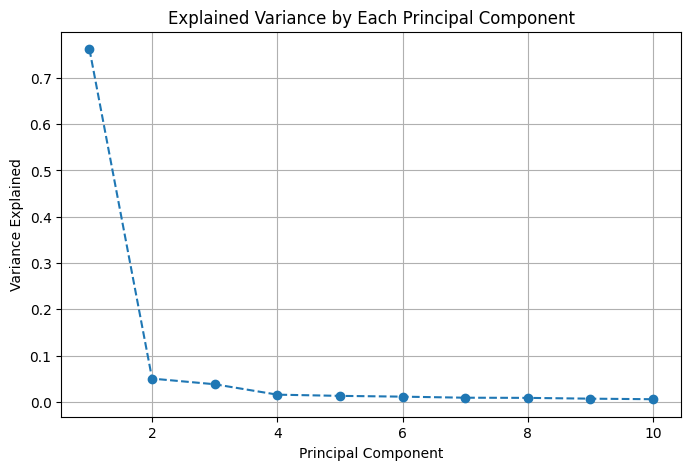

In [5]:
# Standardizing
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

num_components = 10

# Apply PCA
pca = PCA(n_components=num_components)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Training shape after PCA: {X_train_pca.shape}, Test shape: {X_test_pca.shape}")
print("Explained Variance Ratio:", np.sum(pca.explained_variance_ratio_))

explained_variance_ratio = pca.explained_variance_ratio_
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Explained Variance by Each Principal Component')
plt.grid(True)
plt.show()

In [6]:
# Extract component loadings (contributions of genes to each component)
pca_components = pca.fit(X_train)
components_df = pd.DataFrame(pca_components.components_, columns=gene_data.columns) 
components_df.index = [f'PC{i+1}' for i in range(num_components)]
components_df.head()

def get_top_genes_for_component(components_df, n_genes=10):
    top_genes = {}
    for component in components_df.index:
        # Get absolute values to find strongest contributions
        top_gene_indices = components_df.loc[component].abs().nlargest(n_genes).index
        top_genes[component] = top_gene_indices.tolist()
    return top_genes

top_genes = get_top_genes_for_component(components_df)
print("Top Contributing Genes for Each Principal Component:")
for pc, genes in top_genes.items():
    print(f"{pc}: {', '.join(genes)}")


def plot_top_genes_for_component(components_df, component='PC1', n_genes=10):
    top_genes = components_df.loc[component].abs().nlargest(n_genes)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=top_genes.values, y=top_genes.index)
    plt.xlabel('Contribution')
    plt.ylabel('Gene')
    plt.title(f'Top {n_genes} Contributing Genes for {component}')
    plt.show()

Top Contributing Genes for Each Principal Component:
PC1: IGKC, IGHG1, IGLC2, IGLC3, IGLC1, IGKV3__20, MT__ATP8, IGKV3__11, IGKV2D__28, IGHG2
PC2: IGLC3, IGLC2, IGHG1, IGKC, MT__ATP8, IGLC1, IGLV3__1, IGLV3__10, MT__ND4L, MT__CO2
PC3: MT__ATP8, MT__CO2, MT__CO3, MT__ND4L, MT__CO1, MT__ND4, MT__ATP6, Y_RNA.547, IGHG1, IGLC3
PC4: Y_RNA.547, TMSB4XP6, B2M, Y_RNA.117, IGLV3__10, CD74, IGKV2D__28, HLA__DRA, MT__ATP8, IGLV3__1
PC5: Y_RNA.547, IGLV3__10, IGLV3__1, IGKV2D__28, IGLC3, TMSB4XP6, SCGB3A2, IGKV2__28, IGHV3__15, IGHA1
PC6: Y_RNA.547, SCGB3A2, TMSB4XP6, IGLV3__10, IGLV3__1, B2M, IGKV2D__28, MT__ATP8, IGHV3__15, IGKV2__28
PC7: Y_RNA.117, SCGB3A2, TMSB4XP6, IGHG1, Y_RNA.547, MT__ATP8, MT__CO1, MT__CO2, IGLC1, CD74
PC8: SCGB3A2, Y_RNA.117, Y_RNA.547, TMSB4XP6, IGHG1, B2M, IGLC3, RNASE1, IGLC2, SFTPB
PC9: IGHG1, SCGB3A2, B2M, IGLC3, IGLC1, IGLC2, IGKV4__1, IGLV3__10, TMSB4XP6, IGHA1
PC10: IGKV3__11, B2M, TMSB4XP6, IGKV3__15, IGHV3__23, IGHG3, IGHG1, IGHA1, IGLC2, Y_RNA.547


### Data Imbalance Handling

Original dataset: {0: 67, 1: 108, 2: 24}

In [74]:
print(f"==Original training set== \nClass Distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")

==Original training set== 
Class Distribution: {0: 54, 1: 86, 2: 19}


**method I ❌: Calculate class weights -> accuracy of the minor class (class 2) wasn't improved**

In [60]:
# Compute class weights based on inverse frequency
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_dict = {cls: weight for cls, weight in zip(classes, class_weights)}
print("Class weights:", class_weights_dict)

Class weights: {0: 0.9814814814814815, 1: 0.6162790697674418, 2: 2.789473684210526}


**method II: using SMOTE to oversampling on the minor class**

In [10]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_pca, y_train)
print(f"Resampled Training Shape: {X_train_res.shape}, Class Distribution: {dict(zip(*np.unique(y_train_res, return_counts=True)))}")

Resampled Training Shape: (258, 10), Class Distribution: {0: 86, 1: 86, 2: 86}


**method III: using undersampling on the majoirity class**

In [18]:
from imblearn.under_sampling import RandomUnderSampler
undersampler = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = undersampler.fit_resample(X_train_pca, y_train)
print(f"Resampled Training Shape: {X_train_res.shape}, Class Distribution: {dict(zip(*np.unique(y_train_res, return_counts=True)))}")

Resampled Training Shape: (57, 7), Class Distribution: {0: 19, 1: 19, 2: 19}


### CatBoostClassifier

CatBoost is a high-performance open source library for gradient boosting on decision trees.

Advantages of CatBoost library are as follows:-

- Performance: CatBoost provides state of the art results and it is competitive with any leading machine learning algorithm on the performance front.
- Handling Categorical features automatically: We can use CatBoost without any explicit pre-processing to convert categories into numbers. CatBoost converts categorical values into numbers using various statistics on combinations of categorical features and combinations of categorical and numerical features.
- Robust: It reduces the need for extensive hyper-parameter tuning and lower the chances of overfitting also which leads to more generalized models. Although, CatBoost has multiple parameters to tune and it contains parameters like the number of trees, learning rate, regularization, tree depth, fold size, bagging temperature and others.
- Easy-to-use: We can use CatBoost from the command line, using an user-friendly API for both Python and R.

In [8]:
# Implement CatBoost Classifier
cb = CatBoostClassifier(
    random_state=42, 
    # class_weights=class_weights_dict,  # comment out if using SMOTE
    l2_leaf_reg=10,  
    depth=4,  
    learning_rate=0.05,  
    bootstrap_type='Bayesian', 
    # bootstrap_type='Bernoulli', 
    # subsample=0.8,   
    early_stopping_rounds=50,
    verbose=0
    )

# Train the model
cb.fit(X_train_pca, y_train) # comment out if using SMOTE
# cb.fit(X_train_res, y_train_res)

# Predict on test data
y_pred_train = cb.predict(X_train_pca)
y_pred_test = cb.predict(X_test_pca)

**GridSearch**

In [11]:
# Define parameter grid
param_grid = {
    'depth': [3, 4, 5],
    'learning_rate': [0.01, 0.03, 0.05],
    'l2_leaf_reg': [5, 7, 10],
    'iterations': [100, 200, 300],
    'bootstrap_type': ['Bernoulli'],
    'subsample': [0.8, 1.0],
}

# Create model and GridSearchCV
cb = CatBoostClassifier(random_state=42, verbose=0)

# Use balanced accuracy as the evaluation metric
scorer = make_scorer(balanced_accuracy_score)

grid_search = GridSearchCV(
    cb,
    param_grid,
    cv=5,
    scoring=scorer,
    n_jobs=-1
)

# Fit GridSearchCV
grid_search.fit(X_train_res, y_train_res)

# Get best parameters and train final model
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

Best Parameters: {'bootstrap_type': 'Bernoulli', 'depth': 5, 'iterations': 300, 'l2_leaf_reg': 5, 'learning_rate': 0.05, 'subsample': 0.8}


In [12]:
# Train with best parameters
best_model = CatBoostClassifier(**best_params, random_state=42, verbose=0)
best_model.fit(X_train_res, y_train_res)

# Predict and evaluate
y_pred_train = best_model.predict(X_train_pca)
y_pred_test = best_model.predict(X_test_pca)

Balanced Accuracy Train = 0.9760
Balanced Accuracy Test = 0.5865


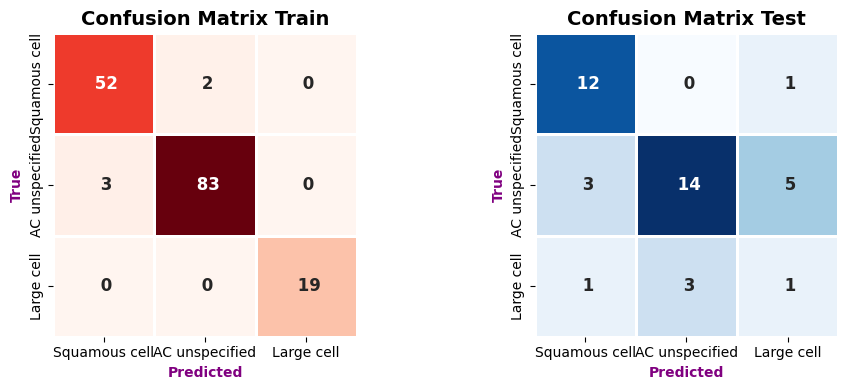

In [13]:
# Evaluation with imbalanced dataset
# Accuracy
bal_acc_train = balanced_accuracy_score(y_train, y_pred_train)  
bal_acc_test = balanced_accuracy_score(y_test, y_pred_test)
print(f"Balanced Accuracy Train = {bal_acc_train:.4f}")
print(f"Balanced Accuracy Test = {bal_acc_test:.4f}")

# Confusion Matrix
label2id = {'Squamous cell':0, 'AC unspecified':1, 'Large cell':2} # 0=squamous cell cancer, 1=AC unspecified, 2=Large cell/ NOS
cf_mx_train = confusion_matrix(y_train, y_pred_train)
cf_mx_test = confusion_matrix(y_test, y_pred_test)

fig,axes = plt.subplots(nrows = 1, ncols = 2, figsize = (10,4))
axes = axes.flat

sns.heatmap(cf_mx_train, cmap = "Reds", annot = True, 
            fmt = " ", cbar = False, square = True, xticklabels = label2id.keys(), 
            yticklabels = label2id.keys(), linewidths = 1.0, annot_kws = {'fontsize':12, 'fontweight':'bold'}, ax = axes[0])
axes[0].set_xlabel("Predicted", fontsize = 10, fontweight = "bold", color = "purple")
axes[0].set_ylabel("True", fontsize = 10, fontweight = "bold", color = "purple")
axes[0].set_title("Confusion Matrix Train", fontsize = 14, fontweight = "bold")

sns.heatmap(cf_mx_test, cmap = "Blues", annot = True, 
            fmt = " ", cbar = False, square = True, xticklabels = label2id.keys(), 
            yticklabels = label2id.keys(), linewidths = 1.0, annot_kws = {'fontsize':12, 'fontweight':'bold'}, ax = axes[1])
axes[1].set_xlabel("Predicted", fontsize = 10, fontweight = "bold", color = "purple")
axes[1].set_ylabel("True", fontsize = 10, fontweight = "bold", color = "purple")
axes[1].set_title("Confusion Matrix Test", fontsize = 14, fontweight = "bold")

fig.tight_layout()
fig.show()

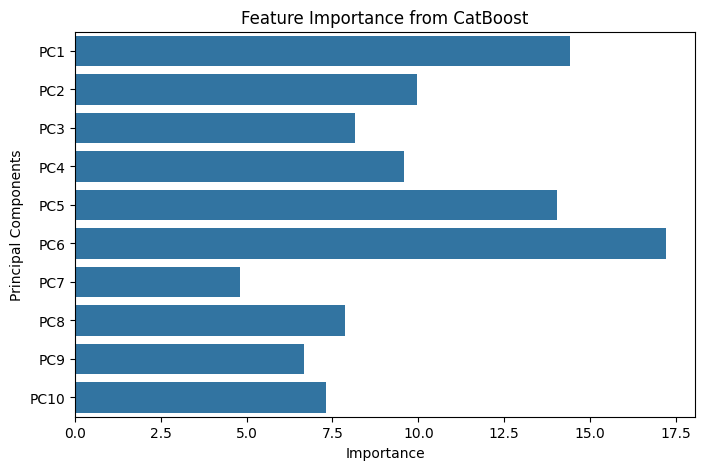

In [14]:
# Plot feature importance
feature_importances = best_model.get_feature_importance()
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importances, y=[f'PC{i+1}' for i in range(len(feature_importances))])
plt.xlabel('Importance')
plt.ylabel('Principal Components')
plt.title('Feature Importance from CatBoost')
plt.show()

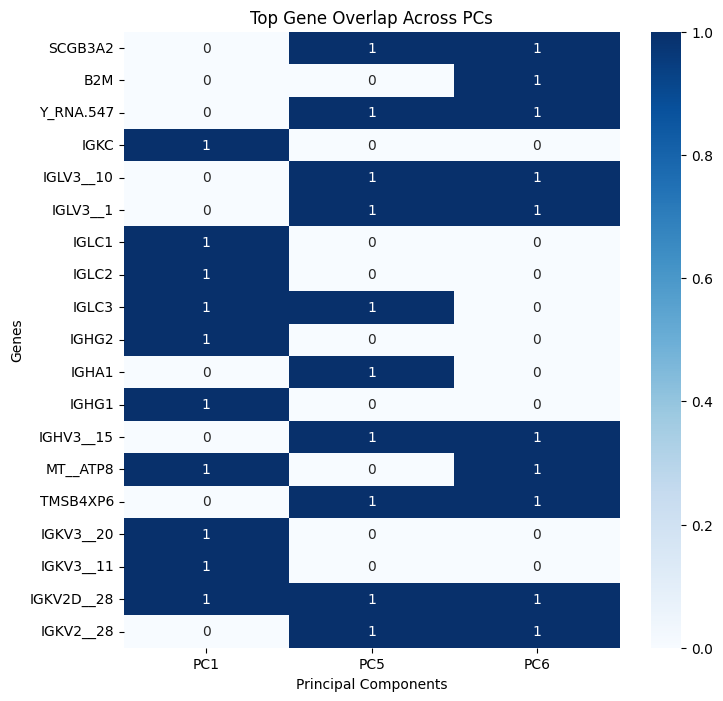

In [21]:
# Choose the top genes for specific PCs
selected_pcs = ['PC1', 'PC5', 'PC6']
top_n = 10

# Extract top contributing genes for each PC
top_genes_df = pd.DataFrame(0, index=X_train.columns, columns=selected_pcs)
for pc in selected_pcs:
    top_genes = components_df.loc[pc].abs().nlargest(top_n).index
    top_genes_df.loc[top_genes, pc] = 1

# Plot heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(top_genes_df.loc[top_genes_df.sum(axis=1) > 0], cmap='Blues', annot=True)
plt.title('Top Gene Overlap Across PCs')
plt.xlabel('Principal Components')
plt.ylabel('Genes')
plt.show()

Explanation:
- Heatmap: Blue cells show where a gene is a top contributor for a PC.
- Annotated: The matrix is labeled with 1 for contribution and 0 for no contribution.
- Filtered: Only genes with at least one contribution are shown.

**Shap**

In [22]:
# Create SHAP values
explainer = shap.Explainer(best_model, X_train_pca)
shap_values = explainer(X_train_pca)

# Visualize summary plot
shap.summary_plot(shap_values, X_train_pca, feature_names=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])

: 

### LightGBM

LightGBM (Light Gradient Boosting Machine) is an open-source gradient boosting framework developed by Microsoft. It is designed for efficiency and speed, particularly in handling large datasets with high-dimensional features. LightGBM is widely used for machine learning tasks, including classification, regression, and ranking.

Key Features of LightGBM:
1. Gradient-Based One-Side Sampling (GOSS) – Prioritizes important data points while reducing the size of the dataset, improving training efficiency.
2. Exclusive Feature Bundling (EFB) – Groups mutually exclusive features to reduce memory usage and speed up computation.
3. Histogram-Based Learning – Bins continuous features into discrete values, reducing computation complexity.
4. Efficient Handling of Large Datasets – Optimized for parallel and GPU processing.
5. Lower Memory Usage – Uses a more compact representation of data than other boosting frameworks like XGBoost.
6. Supports Categorical Features – Handles categorical variables natively without one-hot encoding.

Use Cases:
- Predictive modeling in finance (e.g., fraud detection, credit scoring)
- Recommendation systems
- Click-through rate (CTR) prediction in advertising
- Medical diagnosis and genomic analysis


**Training**

In [1]:
# Convert to LightGBM dataset
train_data = lgb.Dataset(X_train_pca, label=y_train)
test_data = lgb.Dataset(X_test_pca, label=y_test, reference=train_data)

NameError: name 'lgb' is not defined

[LightGBM] [Warning] Unknown parameter: class_weights
[LightGBM] [Warning] Unknown parameter: class_weights
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001203 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 382
[LightGBM] [Info] Number of data points in the train set: 159, number of used features: 7
[LightGBM] [Info] Start training from score -1.079920
[LightGBM] [Info] Start training from score -0.614557
[LightGBM] [Info] Start training from score -2.124465
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

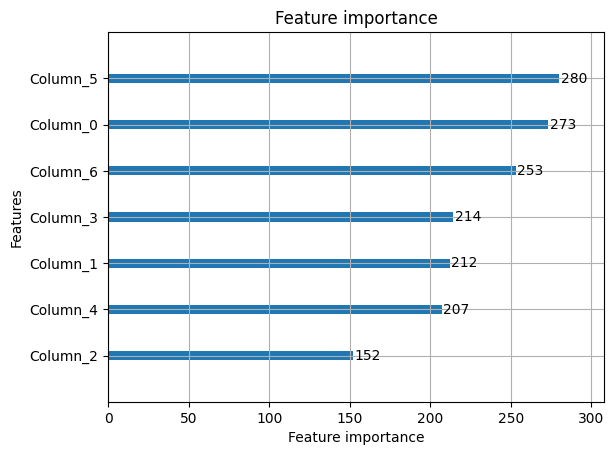

In [ ]:
# Define parameters for LightGBM
params = {
    'boosting_type': 'gbdt',
    'num_leaves': 15,
    'max_depth': 5,
    'learning_rate': 0.1,
    'objective': 'multiclass',
    'num_class': 3,
    'is_unbalance': True,
    'class_weights': class_weights,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'min_data_in_leaf': 20,
    'metric': 'multi_logloss'
}
    
# Train model
model = lgb.train(params, train_data, num_boost_round=10)

# Feature Importance
lgb.plot_importance(model, max_num_features=20)

**Shap Interpretation**

ref: Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. In I. Guyon, U. V. Luxburg, S. Bengio, H. Wallach, R. Fergus, S. Vishwanathan, & R. Garnett (Eds.), *Advances in neural information processing systems 30* (pp. 4765–4774). Curran Associates, Inc. [Paper link](http://papers.nips.cc/paper/7062-a-unified-approach-to-interpreting-model-predictions.pdf)

In [ ]:
# SHAP explanation
model = cb
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_pca)

# Summary plot
shap.summary_plot(shap_values, X_test_pca, class_names=["Squamous Cell", "AC Unspecified", "Large Cell/NOS"])

**Evaluation**

Precision per class: [0.83333333 0.84210526 0.22222222]
Recall per class: [0.76923077 0.72727273 0.4       ]


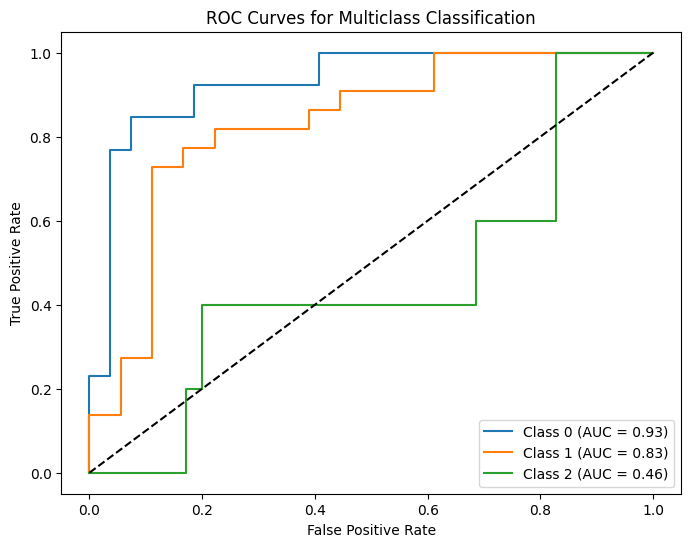

In [12]:
# Convert probabilities to predicted classes
y_pred = model.predict(X_test_pca)
y_pred_classes = np.argmax(y_pred, axis=1)  # Get the predicted class

# Precision & Recall
precision = precision_score(y_test, y_pred_classes, average=None)  # Per-class precision
recall = recall_score(y_test, y_pred_classes, average=None)  # Per-class recall

print("Precision per class:", precision)
print("Recall per class:", recall)

# Binarize labels for ROC computation (One-vs-Rest strategy)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  # Modify class labels accordingly
n_classes = y_test_bin.shape[1]

# Compute ROC curve and ROC AUC
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], "k--")  # Diagonal line for reference
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Multiclass Classification")
plt.legend(loc="lower right")
plt.show()

### Tokenization and Feature Extraction Using Geneformer
ref: https://huggingface.co/dmis-lab/biobert-v1.1

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-v1.1")
model = AutoModel.from_pretrained("dmis-lab/biobert-v1.1")

# Tokenize the gene expression data (text format)
inputs = tokenizer(gene_texts, return_tensors="pt", padding=True, truncation=True)

# Pass the data through BioBERT to get embeddings
with torch.no_grad():
    outputs = model(**inputs)

# Use mean pooling of the last hidden state for embeddings
embeddings = outputs.last_hidden_state.mean(dim=1)

# Now, `embeddings` contains a vector representation for each sample
print(embeddings.shape)

### Identify Oncogenes Using Geneformer Embeddings

Step 1: Prepare Oncogene Data

ref: 
- El-Telbany A, Ma PC. Cancer genes in lung cancer: racial disparities: are there any? Genes Cancer. 2012 Jul;3(7-8):467-80. doi: 10.1177/1947601912465177. PMID: 23264847; PMCID: PMC3527990. https://pmc.ncbi.nlm.nih.gov/articles/PMC3527990/#section2-1947601912465177

In [ ]:
# List of known oncogenes
oncogenes = ["EGFR", "KRAS", "MET", "LKB1", "BRAF", "PIK3CA", "ALK", "RET", "ROS1"]

Step 2: Extract Geneformer Embeddings

Get label genes as oncogenes (1) or non-oncogenes (0)

In [ ]:
# Assuming embeddings were extracted and stored in `embeddings`
# Let's link them to the oncogene labels
# cols = df.columns[3:]
# labels = [ 1 if gene in oncogenes else 0 for gene in cols]
labels = df.columns[gene_texts.isin(oncogenes)].map(lambda gene: 1 if gene in oncogenes else 0)

# Check the shape of the embeddings and labels
print(embeddings.shape, len(labels))

In [ ]:

cols

Index(['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'C1orf112', 'FGR', 'CFH', 'FUCA2',
       'GCLC', 'NFYA',
       ...
       'RP11-415F23.4', 'CYP2D6.2', 'SNORA28', 'Metazoa_SRP.33',
       'GS1-166A23.1', 'XXbac-BPG252P9.9', 'XXbac-BPGBPG55C20.1',
       'RP11-255P5.2', 'MIR4787', 'CTC-527H23.4'],
      dtype='object', length=56685)

In [ ]:

1 in labels

True

Step 3: Train a Classifier

Use the embeddings to train a classifier to predict whether a gene is an oncogene or not

In [ ]:
# Assuming embeddings and labels are aligned
X_train, X_test, y_train, y_test = train_test_split(embeddings.numpy(), labels, test_size=0.2, random_state=42)

# Train a Random Forest classifier
clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate model performance
print("Accuracy:", accuracy_score(y_test, y_pred))

Step 4: Evaluate and Interpret Results

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probabilities for the positive class
y_prob = clf.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()
